# Xenium Prime 5K (codeword)

This notebook demonstrates a spatial isoform/codeword variability workflow on **Xenium Prime 5K data**:

1. Load codeword-level `SpatialData` using `splisosm.io.load_xenium_codeword`.
2. Inspect binned tables and visualize codeword patterns.
3. Run FFT-accelerated spatial variability tests with `SplisosmFFT`.
4. Compare `SplisosmFFT` and `SplisosmNP` on the same binning grid.

Estimated runtime: ~5 min (excluding `SplisosmNP` comparison).

## Preliminary notes

For Xenium Prime 5K datasets, each gene is profiled by multiple [codewords (i.e., exon/junction probe sets)](https://www.10xgenomics.com/support/software/xenium-panel-designer/latest/tutorials/xenium-panel-design-concepts-terms#codewords). To extract codeword-level counts, we utilize the `load_xenium_codeword` function from `splisosm.io` to read `transcripts.zarr.zip` directly. The function will aggregate transcript density into multi-resolution square-bin tables and produce a `SpatialData` object similar to that of the [VisiumHD workflow](./visiumhd_ffpe.ipynb).

**Due to Xenium output data structure changes, if you encounter issues, please re-run the Xenium Ranger (>=v3.1.0) relabel pipeline.** See [10x documentation](https://www.10xgenomics.com/support/software/xenium-ranger/latest/analysis/running-pipelines/XR-relabel) for guidance.

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import spatialdata as sd
import spatialdata_plot  # Registers plotting accessors
from spatialdata import rasterize_bins

from splisosm import SplisosmFFT, SplisosmNP
from splisosm.utils import counts_to_ratios
from splisosm.io import load_xenium_codeword

/Users/jysumac/miniforge3/envs/splisosm_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (6, 4)

## Configure paths and core parameters

In [3]:
# Required: Xenium Ranger output directory (either the `outs` dir itself or its parent)
# xenium_prime_outs = Path('/path/to/xenium_prime_5k/outs')
xenium_prime_outs = Path('/Users/jysumac/Projects/SPLISOSM_paper/data/xenium_5k_mouse_brain/codeword-relabel/outs')

# Optional cache path
sdata_zarr = xenium_prime_outs / 'sdata_codeword.filtered.zarr'

# Resolutions (um) to materialize
spatial_resolutions = [8.0, 16.0]

# Primary analysis table / bins
test_table = 'square_016um'
test_bins_element = 'square_016um_bins'

# Feature grouping and filters
group_iso_by = 'gene_symbol'
gene_name_col = 'gene_symbol'
min_counts = 10
min_bin_pct = 0.0

# Xenium transcript filter
quality_threshold = 20.0

## Load codeword-level `SpatialData`

We use a [Xenium Prime 5K mouse brain fresh frozen dataset](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-mouse-brain) from 10x Genomics (5K Mouse Pan Tissue and Pathways Panel). Here we use the `load_xenium_codeword` function to build a `SpatialData` object where per-codeword density is computed at multi-resolution. The function wraps [`spatialdata-io.xenium`](https://spatialdata.scverse.org/projects/io/en/latest/generated/spatialdata_io.xenium.html).

In [4]:
%%time
if sdata_zarr.exists():
    print('Loading cached SpatialData...')
    sdata = sd.read_zarr(sdata_zarr)
else:
    print('Building Xenium codeword SpatialData from transcript chunks...')
    sdata = load_xenium_codeword(
        path=xenium_prime_outs,
        spatial_resolutions=spatial_resolutions,
        quality_threshold=quality_threshold,
        n_jobs=-1,
        chunk_batch_size=64,
        counts_layer_name='counts',
        create_square_shapes=True,
        show_progress=True,
    )
    # Optional: cache for faster reruns
    # sdata.write(sdata_zarr)

sdata

Building Xenium codeword SpatialData from transcript chunks...


/Users/jysumac/miniforge3/envs/splisosm_test/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


CPU times: user 2min 31s, sys: 39.3 s, total: 3min 10s
Wall time: 1min 49s


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 23912, 34154), (4, 11956, 17077), (4, 5978, 8538), (4, 2989, 4269), (4, 1494, 2134)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
│     └── 'nucleus_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (63173, 1) (2D shapes)
│     ├── 'nucleus_boundaries': GeoDataFrame shape: (63036, 1) (2D shapes)
│     ├── 'square_008um_bins': GeoDataFrame shape: (576580, 1) (2D shapes)
│     └── 'square_016um_bins': GeoDataFrame shape: (144372, 1) (2D shapes)
└── Tables
      ├── 'square_008um': AnnData (576580, 11163)
      ├── 'square_016um': AnnData (144372, 11163)
      └── 'table': AnnData (63173, 5006)
with coordinate systems:
    ▸ 'global', with elements:


Different than the segmented cell-by-gene table `sdata.tables['table']`, `sdata.tables['square_xxxum']` are **bin-by-codeword tables** at multiple resolutions. Each codeword corresponds to a specific probe set for a gene, allowing for more granular spatial analysis.

In [5]:
sdata.tables[test_table].var.head(5)

,codeword_id,gene_symbol,feature_id
var_name,,,
Sirt2|3,3,Sirt2,Sirt2|3
Egfl7|4,4,Egfl7,Egfl7|4
Rpe65|6,6,Rpe65,Rpe65|6
NegControlProbe_00017|7,7,NegControlProbe_00017,NegControlProbe_00017|7
Nr4a3|10,10,Nr4a3,Nr4a3|10


Our Xenium Prime 5K data is denser than the VisiumHD FFPE mouse brain data, so we may use a smaller bin size (e.g., 10um) to capture more spatial details.

In [6]:
def summarize_table(adata):
    X = adata.layers['counts'] if 'counts' in adata.layers else adata.X
    if hasattr(X, 'nnz'):
        nnz = int(X.nnz)
        total = int(X.shape[0] * X.shape[1])
        density = nnz / total if total else np.nan
    else:
        arr = np.asarray(X)
        nnz = int(np.count_nonzero(arr))
        total = int(arr.size)
        density = nnz / total if total else np.nan
    return {
        'n_features': int(adata.n_vars),
        'n_bins': int(adata.n_obs),
        'count_mtx_density': density,
    }

rows = []
for key in sorted(sdata.tables.keys()):
    if key.startswith('square_'):
        rows.append({'table': key, **summarize_table(sdata.tables[key])})

table_summary = pd.DataFrame(rows).sort_values('table')
table_summary

,table,n_features,n_bins,count_mtx_density
0,square_008um,11163,576580,0.018701
1,square_016um,11163,144372,0.058018


For illustration purposes, we will use the binned `AnnData` `square_016um` as the primary analysis table and use the shape `square_016um_bins` (i.e., spatial grid with 16x16um bins) for rasterization, similar to the VisiumHD workflow.

In [7]:
print('Tables:', sorted(sdata.tables.keys()))
print('Shapes:', sorted(getattr(sdata, 'shapes', {}).keys()))
print('Images:', sorted(getattr(sdata, 'images', {}).keys()))

if test_table not in sdata.tables:
    raise ValueError(f'{test_table} is not available. Choose from: {sorted(sdata.tables.keys())}')
if test_bins_element not in sdata.shapes:
    raise ValueError(f'{test_bins_element} is not available. Choose from: {sorted(sdata.shapes.keys())}')

adata_test = sdata.tables[test_table]
if group_iso_by not in adata_test.var.columns:
    raise ValueError(f'{group_iso_by} not found in {test_table}.var columns')

print(f'Using table={test_table}, bins={test_bins_element}')
print(f'Grouping column={group_iso_by}, display names={gene_name_col}')

Tables: ['square_008um', 'square_016um', 'table']
Shapes: ['cell_boundaries', 'nucleus_boundaries', 'square_008um_bins', 'square_016um_bins']
Images: ['morphology_focus']
Using table=square_016um, bins=square_016um_bins
Grouping column=gene_symbol, display names=gene_symbol


## Optional morphology and segmentation preview

INFO     Rasterizing image for faster rendering.                                                                   


/Users/jysumac/miniforge3/envs/splisosm_test/lib/python3.12/site-packages/pims/tiff_stack.py:131: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file


INFO     Rasterizing image for faster rendering.                                                                   
CPU times: user 4min 51s, sys: 26 s, total: 5min 17s
Wall time: 1min 11s


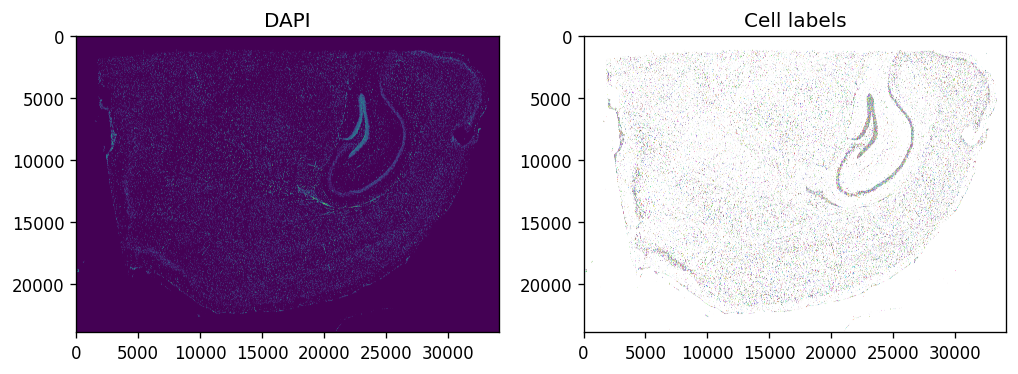

In [8]:
%%time
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
sdata.pl.render_images(f"morphology_focus", channel='DAPI').pl.show(
    coordinate_systems=f"global",
    ax=axes[0], title="DAPI", colorbar=False
)
sdata.pl.render_labels(f"cell_labels").pl.show(
    coordinate_systems=f"global",
    ax=axes[1], title="Cell labels"
)

## Rasterize bins and visualize one codeword

In [9]:
%%time
# rasterize_bins() expects a CSC matrix for best compatibility
adata_plot = sdata.tables[test_table]
adata_plot.X = adata_plot.layers['counts']
if hasattr(adata_plot.X, 'tocsc') and getattr(adata_plot.X, 'format', None) != 'csc':
    adata_plot.X = adata_plot.X.tocsc()

raster_key = f'rasterized_{test_table}'
sdata[raster_key] = rasterize_bins(
    sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key='array_col',
    row_key='array_row',
)
print('Created:', raster_key)

Created: rasterized_square_016um
CPU times: user 1.29 s, sys: 435 ms, total: 1.72 s
Wall time: 2.79 s


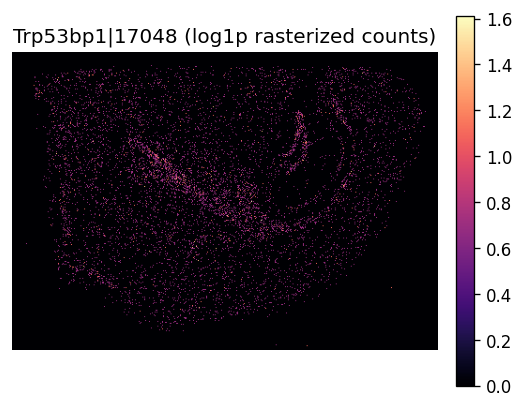

CPU times: user 81.6 ms, sys: 11.4 ms, total: 93.1 ms
Wall time: 102 ms


In [11]:
%%time
feature_name = 'Trp53bp1|17048' # Trp53bp1
img = np.asarray(sdata[f'rasterized_{test_table}'].sel(c=feature_name).values).squeeze()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.log1p(img), cmap='magma')
ax.set_title(f'{feature_name} (log1p rasterized counts)')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Spatial variability testing with `SplisosmFFT`

In [12]:
model = SplisosmFFT(neighbor_degree=1, rho=0.99)
model.setup_data(
    sdata=sdata,
    bins=test_bins_element,
    table_name=test_table,
    col_key='array_col',
    row_key='array_row',
    layer='counts',
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
)
print(model)

=== FFT SPLISOSM model for spatial isoform testings
- Number of genes: 4972
- Number of observed spots: 144372
- Number of raster cells: 144372
- Average number of isoforms per gene: 2.091713596138375
=== Test results
- Spatial variability test: NA
- Differential usage test: NA


Before running the test, we can again check gene-level summaries to confirm that Xenium Prime 5K data contains multiple codewords per gene.

In [13]:
%%time
gene_meta = model.extract_feature_summary(level='gene')
gene_meta.sort_values('perplexity', ascending=False).head(5)

Genes: 100%|██████████| 4972/4972 [00:11<00:00, 421.04it/s]


CPU times: user 10.6 s, sys: 1.76 s, total: 12.4 s
Wall time: 12.4 s


,n_isos,perplexity,pct_bin_on,count_avg,count_std
gene,,,,,
Gnao1,4,3.979105,0.616671,4.027173,5.066839
Apob,4,3.952770,0.001385,0.002016,0.141543
Gja1,4,3.929913,0.375149,1.565989,3.772387
Acox1,4,3.921495,0.459334,1.000139,1.440174
Ghr,4,3.909349,0.041268,0.045805,0.233034


In [14]:
%%time
model.test_spatial_variability(
    method='hsic-ir',
    ratio_transformation='none',
    n_jobs=-1,
    print_progress=True,
)
sv_res_fft = model.get_formatted_test_results('sv').sort_values('pvalue_adj')

SV (hsic-ir): 100%|██████████| 4972/4972 [01:07<00:00, 73.18it/s]


CPU times: user 2min 45s, sys: 33.7 s, total: 3min 18s
Wall time: 1min 8s


In [15]:
sig_001 = int((sv_res_fft['pvalue_adj'] < 0.01).sum())
print(
    'Spatially variable genes (FDR < 0.01): '
    f'{sig_001} out of {sv_res_fft.shape[0]} total genes'
)
sv_res_fft.head(5)

Spatially variable genes (FDR < 0.01): 2144 out of 4972 total genes


,gene,statistic,pvalue,pvalue_adj
2061,Zfp281,1.777472e-06,0.0,0.0
2310,Ddit3,1.621363e-06,0.0,0.0
3851,Ttll6,2.199914e-08,0.0,0.0
138,Grpel1,5.033253e-07,0.0,0.0
4577,Ifit3,4.637240e-07,0.0,0.0


We can use negative control probes to estimate false positive rates due to technical noise (e.g., probe malfunction or non-specific hybridization).

In [16]:
ctrl_genes = (
    sv_res_fft['gene'].str.startswith('NegControlProbe') |
    sv_res_fft['gene'].str.startswith('Intergenic')
)
sig_001_ctrl = int((sv_res_fft.loc[ctrl_genes, 'pvalue_adj'] < 0.01).sum())
print(
    'Spatially variable negative control genes (FDR < 0.01): '
    f'{sig_001_ctrl} out of {sv_res_fft.loc[ctrl_genes].shape[0]} total control genes'
)
sv_res_fft.loc[ctrl_genes].sort_values('pvalue_adj').head(5)

Spatially variable negative control genes (FDR < 0.01): 8 out of 57 total control genes


,gene,statistic,pvalue,pvalue_adj
2475,Intergenic_Region_105_part_73,2.199321e-08,8.115485e-17,5.942591e-16
463,NegControlProbe_00041,5.502025e-09,1.810361e-07,7.667050e-07
731,NegControlProbe_00003,5.328555e-09,3.139711e-07,1.294415e-06
1042,Intergenic_Region_10757_part_30,8.702548e-09,9.215231e-05,2.883457e-04
1105,NegControlProbe_00014,1.269646e-08,2.698407e-04,7.892047e-04


## Visualize selected significant genes

In [17]:
def ensure_rasterized(sdata, bin_table: str, bin_element: str, layer: str = 'counts'):
    raster_key = f'rasterized_{bin_table}_{layer}'
    if raster_key in sdata.images:
        return raster_key

    adata = sdata.tables[bin_table]
    adata.X = adata.layers[layer]
    if hasattr(adata.X, 'tocsc') and getattr(adata.X, 'format', None) != 'csc':
        adata.X = adata.X.tocsc()

    sdata[raster_key] = rasterize_bins(
        sdata,
        bins=bin_element,
        table_name=bin_table,
        col_key='array_col',
        row_key='array_row',
    )
    return raster_key

In [18]:
def plot_gene_codeword_maps(
    sdata,
    bin_table: str,
    bin_element: str,
    gene_id: str,
    var_meta: pd.DataFrame | None = None,
    group_col: str = 'gene_symbol',
    max_features: int = 4,
    hide_zero_count: bool = True,
    hide_zero_ratio: bool = True,
):
    adata = sdata.tables[bin_table]
    if var_meta is None:
        var_meta = adata.var.copy()

    if group_col not in var_meta.columns:
        raise ValueError(f"'{group_col}' not found in var metadata columns")

    feature_names = var_meta.index[var_meta[group_col].astype(str) == str(gene_id)].tolist()
    if len(feature_names) == 0:
        raise ValueError(f"No features found for gene '{gene_id}'")

    feature_names = feature_names[: min(len(feature_names), max_features)]

    raster_key = ensure_rasterized(sdata, bin_table=bin_table, bin_element=bin_element)
    data = sdata[raster_key].sel(c=feature_names).values
    counts_cube = np.moveaxis(np.asarray(data, dtype=float), 0, -1)

    counts_flat = counts_cube.reshape(-1, counts_cube.shape[-1])
    ratios_flat = counts_to_ratios(counts_flat, transformation='none', nan_filling='none')
    ratios_cube = ratios_flat.numpy().reshape(counts_cube.shape)

    n_feat = counts_cube.shape[-1]
    fig, axes = plt.subplots(2, n_feat, figsize=(4 * n_feat, 7), squeeze=False)

    vmax_ratio = np.nanpercentile(ratios_cube, 99) if np.isfinite(ratios_cube).any() else 1.0

    for i, feature in enumerate(feature_names):
        c = counts_cube[:, :, i]
        r = ratios_cube[:, :, i]

        if hide_zero_count:
            c = np.where(c == 0, np.nan, c)
        if hide_zero_ratio:
            r = np.where(r == 0, np.nan, r)

        im0 = axes[0, i].imshow(np.log1p(c), cmap='Purples', vmin=0.0)
        axes[0, i].set_title(f'Count (log1p)\n{feature}')
        axes[0, i].axis('off')
        fig.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

        im1 = axes[1, i].imshow(r, cmap='Reds', vmin=0.0, vmax=vmax_ratio)
        axes[1, i].set_title(f'Ratio\n{feature}')
        axes[1, i].axis('off')
        fig.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

    fig.suptitle(f'Gene {gene_id} | showing {n_feat} features | {bin_table}', y=1.02)
    fig.tight_layout()
    plt.show()

In [19]:
top_genes = sv_res_fft.head(10)['gene'].astype(str).tolist()
top_genes[:5]

['Zfp281', 'Ddit3', 'Ttll6', 'Grpel1', 'Ifit3']

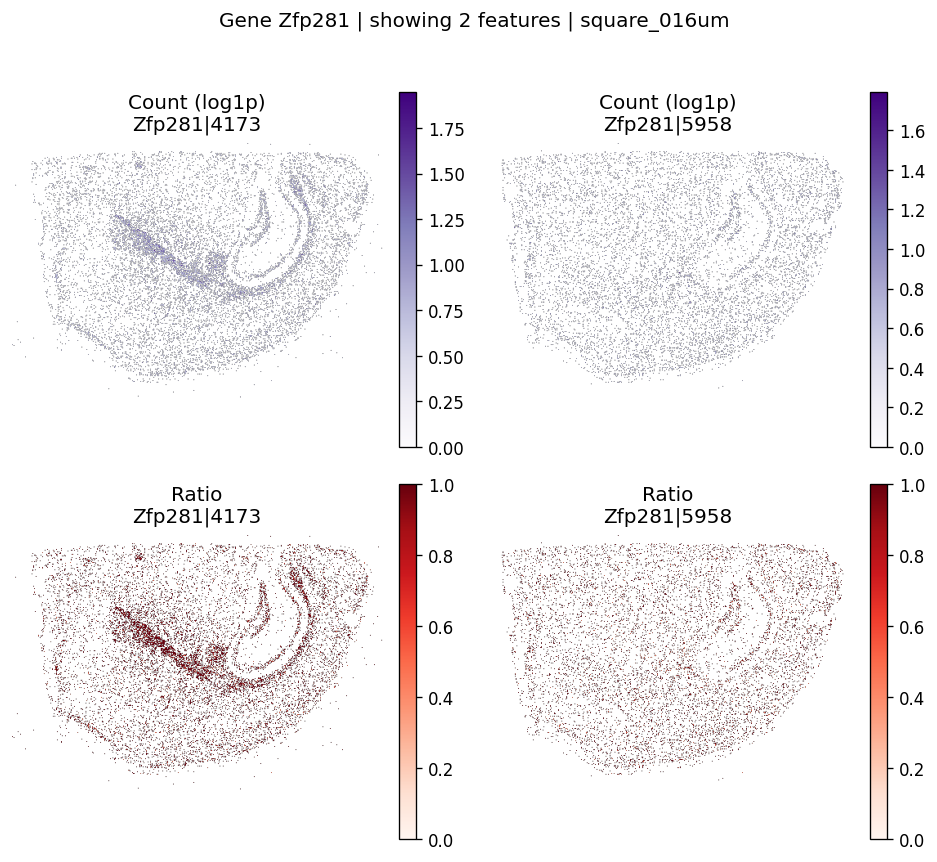

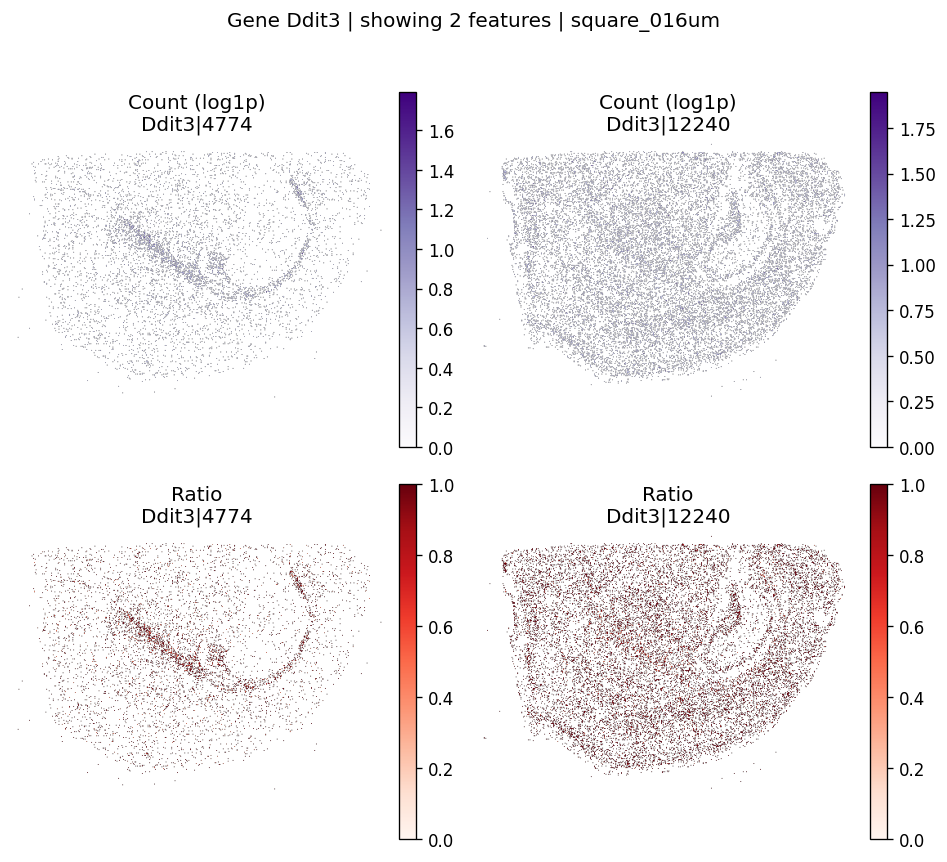

In [20]:
for gene_id in top_genes[:2]:
    plot_gene_codeword_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        var_meta=sdata.tables[test_table].var,
        group_col=group_iso_by,
        max_features=6,
        hide_zero_ratio=True,
    )

And also for negative control probes

In [21]:
top_ctrl_genes = sv_res_fft.loc[ctrl_genes].head(10)['gene'].astype(str).tolist()
top_ctrl_genes[:5]

['Intergenic_Region_105_part_73',
 'NegControlProbe_00041',
 'NegControlProbe_00003',
 'Intergenic_Region_10757_part_30',
 'NegControlProbe_00014']

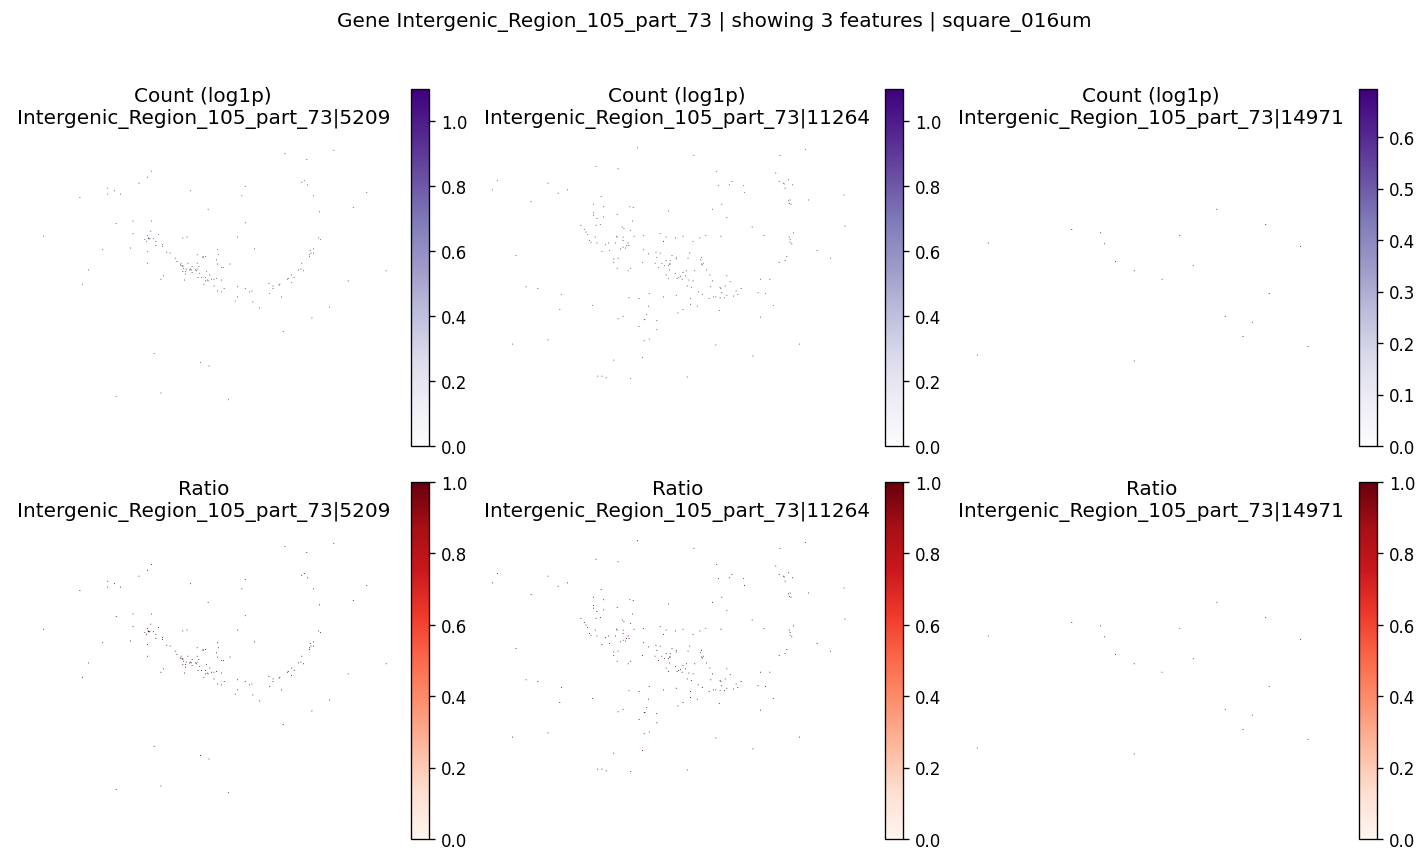

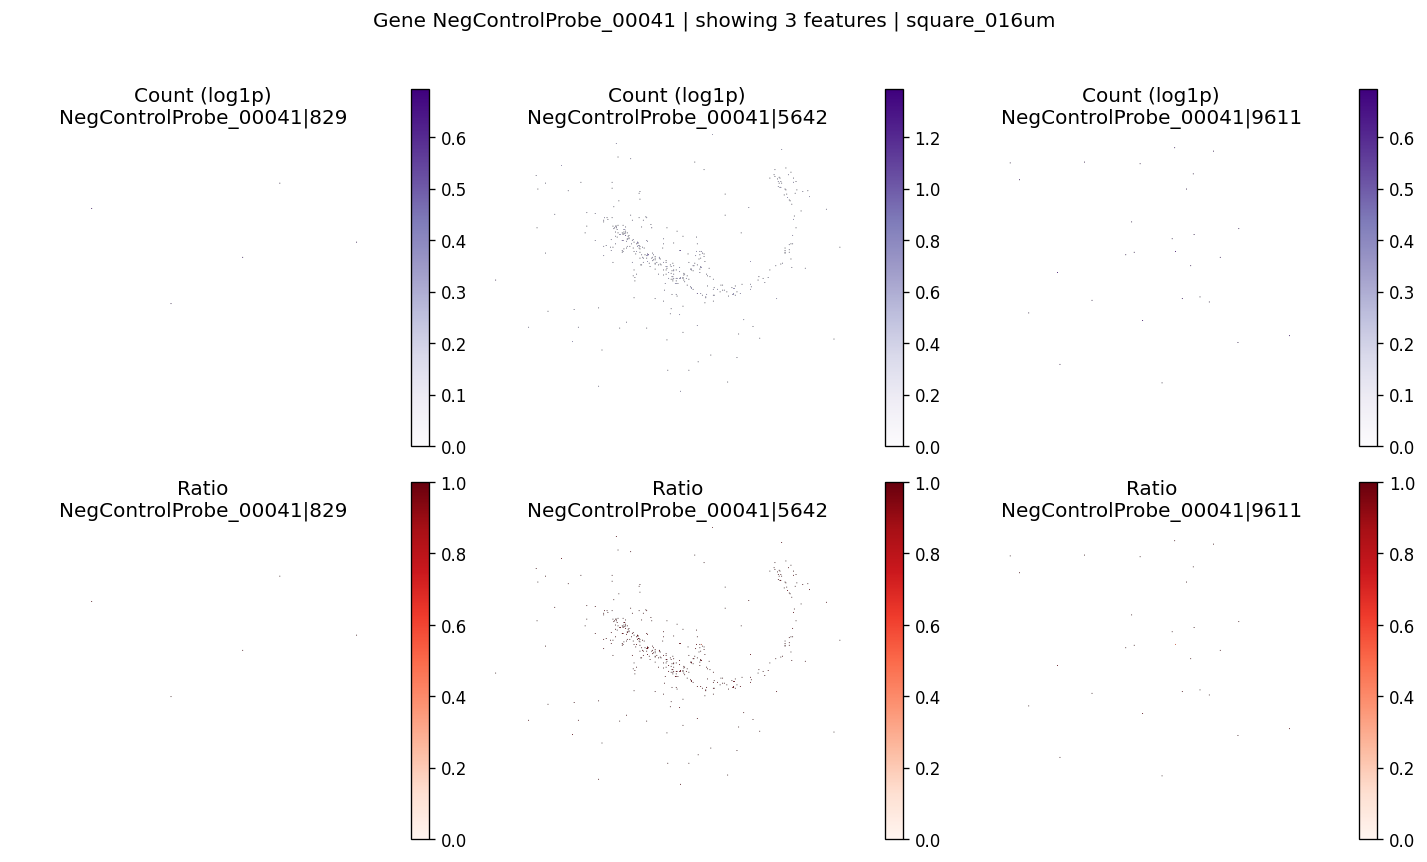

In [22]:
for gene_id in top_ctrl_genes[:2]:
    plot_gene_codeword_maps(
        sdata=sdata,
        bin_table=test_table,
        bin_element=test_bins_element,
        gene_id=gene_id,
        var_meta=sdata.tables[test_table].var,
        group_col=group_iso_by,
        max_features=6,
        hide_zero_ratio=True,
    )

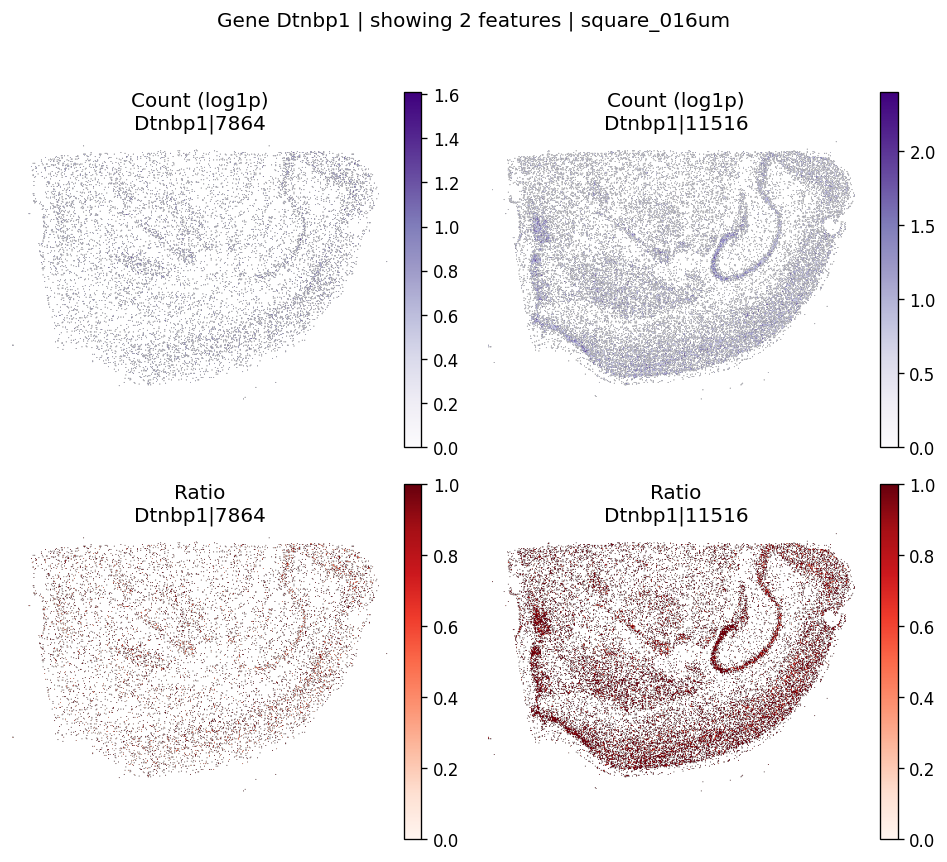

CPU times: user 245 ms, sys: 32.1 ms, total: 277 ms
Wall time: 281 ms


In [23]:
%%time
# Example: inspect a specific gene manually
plot_gene_codeword_maps(
    sdata=sdata,
    bin_table=test_table,
    bin_element=test_bins_element,
    gene_id='Dtnbp1',
    var_meta=sdata.tables[test_table].var,
    group_col=group_iso_by,
    max_features=6,
    hide_zero_ratio=True,
)

## Method comparison: `SplisosmFFT` vs `SplisosmNP`

For a direct method comparison, we run `SplisosmNP` on the same `AnnData` table used by `SplisosmFFT`.

In [24]:
%%time
model_np = SplisosmNP()
model_np.setup_data(
    adata=sdata.tables[test_table],
    spatial_key='spatial',
    layer='counts',
    approx_rank=20,
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
)
print(model_np)

=== Non-parametric SPLISOSM model for spatial isoform testings
- Number of genes: 4972
- Number of spots: 144372
- Number of covariates: 0
- Average number of isoforms per gene: 2.091713596138375
=== Test results
- Spatial variability test: NA
- Differential usage test: NA
CPU times: user 8min 6s, sys: 7.83 s, total: 8min 14s
Wall time: 6min 37s


In [25]:
%%time
model_np.test_spatial_variability(
    method='hsic-ir',
    ratio_transformation='none',
    print_progress=True,
)

100%|██████████| 4972/4972 [00:45<00:00, 108.19it/s]

CPU times: user 41.7 s, sys: 16.3 s, total: 58 s
Wall time: 46 s


In [26]:
sv_np = model_np.get_formatted_test_results('sv')[['gene', 'pvalue']].copy()
sv_np = sv_np.rename(columns={'pvalue': 'pvalue_np'})

comparison = sv_res_fft[['gene', 'pvalue']].copy()
comparison = comparison.rename(columns={'pvalue': 'pvalue_fft'})
comparison = comparison.merge(sv_np, on='gene', how='inner')

corr, _ = spearmanr(comparison['pvalue_fft'], comparison['pvalue_np'])

print(f'Genes tested in both methods: {len(comparison)}')
print(f'P-value correlation (Spearman rho): {corr:.4f}')

Genes tested in both methods: 4972
P-value correlation (Spearman rho): 0.7794


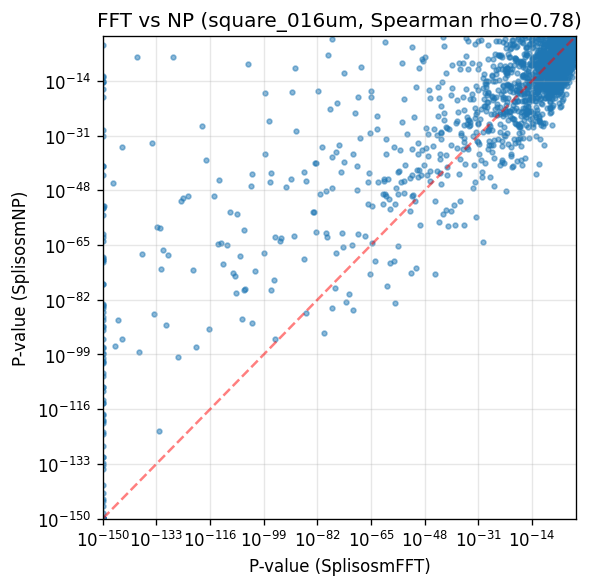

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
x = comparison['pvalue_fft'].to_numpy()
y = comparison['pvalue_np'].to_numpy()

ax.scatter(x + 1e-150, y + 1e-150, s=8, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('P-value (SplisosmFFT)')
ax.set_ylabel('P-value (SplisosmNP)')
ax.set_title(f'FFT vs NP ({test_table}, Spearman rho={corr:.2f})')
ax.grid(True, alpha=0.3)

lims = [1e-150, 1.0]
ax.plot(lims, lims, 'r--', alpha=0.5, linewidth=1.5)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

## Summary

- `load_xenium_codeword` enables direct codeword-level multi-resolution binning from Xenium outputs.
- `SplisosmFFT` is an efficient default on regular square grids and yield highly similar results to `SplisosmNP`.

## For reproducibility

In [28]:
import sys
from datetime import date
import splisosm

print('Last updated:', date.today())
print('Python:', sys.version.split()[0])
print('splisosm:', getattr(splisosm, '__version__', 'unknown'))

Last updated: 2026-03-15
Python: 3.12.12
splisosm: 1.0.4
